# Głębokie Uczenie w Praktyce
## Laboratorium 10
### Mateusz Horczak


#### Ćwiczenie 1. Załaduj dane uczące (fashion_mnist) i podejrzyj ich zawartość

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

def load_real_samples():
    (train_x, train_y), (_, _) = keras.datasets.fashion_mnist.load_data()

    train_x = train_x[train_y.flatten() == 1]

    x = np.expand_dims(train_x, axis=-1)

    x = x.astype('float32')

    x = (x - 127.5) / 127.5
    return x

dataset = load_real_samples()
print("Dataset shape:", dataset.shape)

2026-05-18 17:08:20.649166: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-18 17:08:20.698633: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-18 17:08:22.265113: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 52s 2us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 8s 2us/step
Dataset shape: (6000, 28, 28, 1)


#### Ćwiczenie 2. Budowa dyskryminatora

In [2]:
def build_discriminator():
    model = keras.Sequential([
        keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(128, kernel_size=3, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(128, kernel_size=3, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Flatten(),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ], name="discriminator")
    return model

discriminator = build_discriminator()
discriminator.summary()

/home/mateusz/PycharmProjects/glebokie_uczenie_w_praktyce/.venv/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
2026-05-18 17:09:28.032518: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 413,185 (1.58 MB)

 Trainable params: 413,185 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

#### Ćwiczenie 3. Budowa generatora

In [6]:
latent_dim = 128

def build_generator(latent_size):
    model = keras.Sequential([
        keras.Input(shape=(latent_size,)),
        layers.Dense(7 * 7 * 128),
        layers.Reshape((7, 7, 128)),

        # Upsampling from 7x7 to 14x14
        layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),

        # Upsampling from 14x14 to 28x28
        layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),

        # Final layer outputting 28x28x1 image
        layers.Conv2D(1, kernel_size=7, padding="same", activation="tanh"),
    ], name="generator")
    return model

generator = build_generator(latent_dim)
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 14, 14, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 28, 28, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,339,905 (5.11 MB)

 Trainable params: 1,339,905 (5.11 MB)

 Non-trainable params: 0 (0.00 B)

#### Ćwiczenie 4. Budowa GAN- train_step

In [7]:
class GAN(keras.Model):
    def __init__(self, discriminator_model, generator_model, latent_size):
        super(GAN, self).__init__()
        self.discriminator = discriminator_model
        self.generator = generator_model
        self.latent_dim = latent_size

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super(GAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn
        self.d_loss_metric = keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))

        generated_images = self.generator(random_latent_vectors)
        combined_images = tf.concat([generated_images, real_images], axis=0)

        labels = tf.concat([tf.ones((batch_size, 1)), tf.zeros((batch_size, 1))], axis=0)
        labels += 0.05 * tf.random.uniform(tf.shape(labels))

        with tf.GradientTape() as tape:
            predictions = self.discriminator(combined_images)
            d_loss = self.loss_fn(labels, predictions)
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_weights))

        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        misleading_labels = tf.zeros((batch_size, 1))

        with tf.GradientTape() as tape:
            predictions = self.discriminator(self.generator(random_latent_vectors))
            g_loss = self.loss_fn(misleading_labels, predictions)
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)

        return {"d_loss": self.d_loss_metric.result(), "g_loss": self.g_loss_metric.result()}

#### Ćwiczenie 5. Trenowanie GAN

In [8]:
EPOCHS = 10
BATCH_SIZE = 64

gan = GAN(discriminator_model=discriminator, generator_model=generator, latent_size=latent_dim)
gan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss_fn=keras.losses.BinaryCrossentropy()
)

history = gan.fit(
    dataset,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/10


2026-05-18 17:12:17.133378: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 25690112 exceeds 10% of free system memory.
2026-05-18 17:12:17.137461: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 25690112 exceeds 10% of free system memory.
2026-05-18 17:12:17.276391: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 25690112 exceeds 10% of free system memory.
2026-05-18 17:12:17.562687: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 25690112 exceeds 10% of free system memory.
2026-05-18 17:12:17.562715: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 39337984 exceeds 10% of free system memory.


94/94 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - d_loss: 0.3867 - g_loss: 1.1027
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - d_loss: 0.2236 - g_loss: 1.8268
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - d_loss: 0.3649 - g_loss: 2.2429
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - d_loss: 0.3876 - g_loss: 2.0521
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - d_loss: 0.5693 - g_loss: 1.4508
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - d_loss: 0.4796 - g_loss: 1.7075
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - d_loss: 0.5684 - g_loss: 1.3807
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - d_loss: 0.6148 - g_loss: 1.2655
Epoch 9/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - d_loss: 0.5214 - g_loss: 1.3929
Epoch 10/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - d_loss: 0.5946 - g_loss: 1.2483


#### Ćwiczenie 6. Generowanie i wyświetlanie obrazów po wytrenowaniu GAN

X.shape: (100, 28, 28, 1)


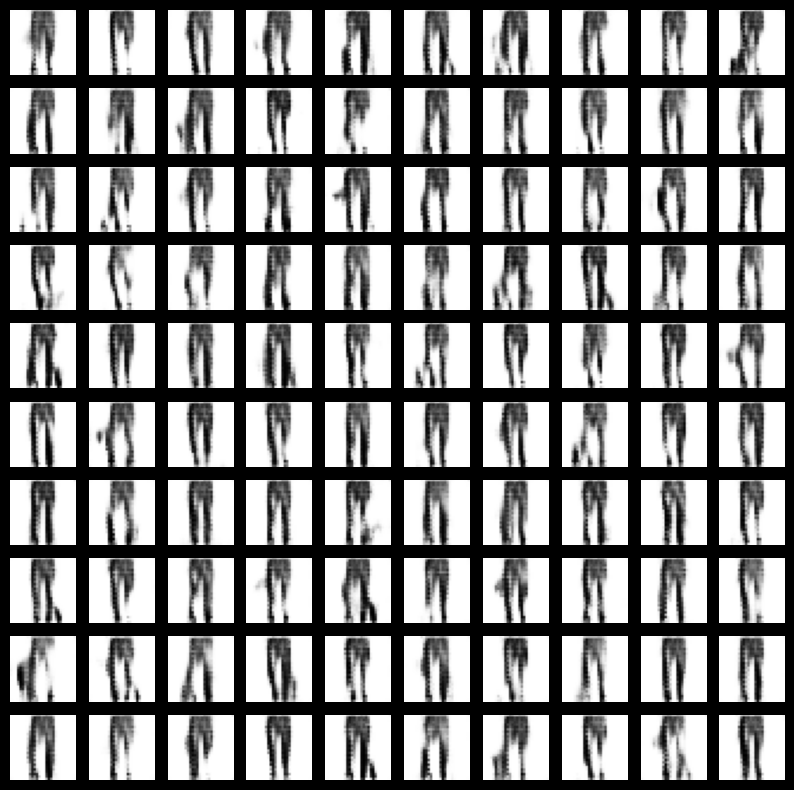

In [9]:
def generate_and_show_images(gen_model, latent_size, num_images=100):
    random_vectors = tf.random.normal(shape=(num_images, latent_size))
    generated = gen_model(random_vectors)

    generated = (generated * 127.5) + 127.5
    generated = generated.numpy()

    print(f"X.shape: {generated.shape}")

    plt.figure(figsize=(10, 10))
    for i in range(num_images):
        plt.subplot(10, 10, i + 1)
        plt.axis('off')
        plt.imshow(generated[i, :, :, 0], cmap='gray_r')
    plt.show()

generate_and_show_images(generator, latent_dim)

#### Ćwiczenie 7. Wizualizuj straty dyskryminatora i GAN na wykresie

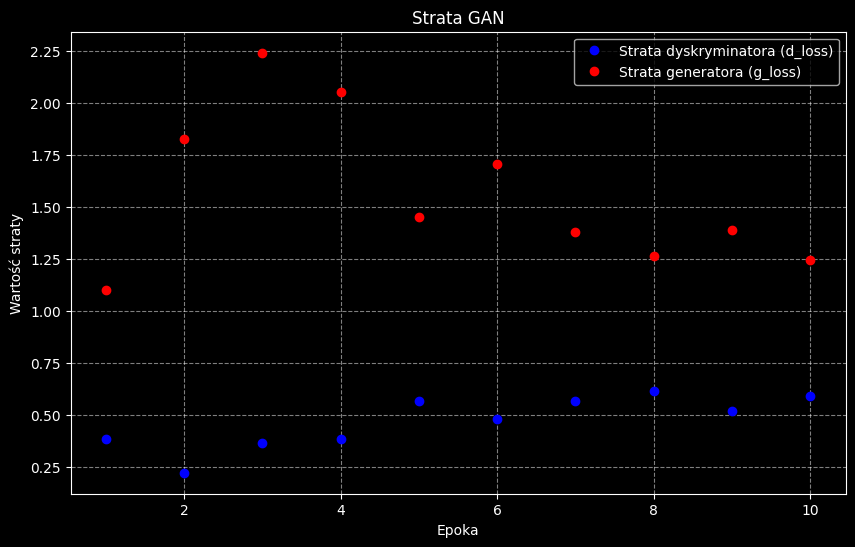

In [10]:
def plot_training_loss(training_history):
    d_loss = training_history.history['d_loss']
    g_loss = training_history.history['g_loss']
    epochs_range = range(1, len(d_loss) + 1)

    plt.figure(figsize=(10, 6))

    plt.plot(epochs_range, d_loss, 'bo', label='Strata dyskryminatora (d_loss)')
    plt.plot(epochs_range, g_loss, 'ro', label='Strata generatora (g_loss)')

    plt.title('Strata GAN')
    plt.xlabel('Epoka')
    plt.ylabel('Wartość straty')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

plot_training_loss(history)

#### Ćwiczenie 8. Przystosuj GAN do uczenia z innym parametrami

In [ ]:
experimental_latent_dim = 64

exp_discriminator = build_discriminator()
exp_generator = build_generator(experimental_latent_dim)

exp_gan = GAN(
    discriminator_model=exp_discriminator,
    generator_model=exp_generator,
    latent_size=experimental_latent_dim
)

exp_gan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss_fn=keras.losses.BinaryCrossentropy()
)

experimental_history = exp_gan.fit(
    dataset,
    epochs=5,
    batch_size=128
)

plot_training_loss(experimental_history)

Epoch 1/5
23/47 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - d_loss: 0.5009 - g_loss: 0.9562